In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import math
import matplotlib.pyplot as plt




In [ ]:
class SVMClassifier1:
    def __init__(self,tol = 1e-8,C = 1.0,no_passes = 10):
        self.tol = tol
        self.C = C
        self.w = None
        self.b = None
        self.max_passes = no_passes
        self.alpha = None
        self.Pos_support_vec = None
        self.neg_support_vec = None
    def pridict(self,x_i):
        return np.dot(x_i, self.w) + self.b
    def K(self,x_i,x_j):
        return np.dot(x_i.T,x_j)
    def __w__(self,x_train,y_train,alpha):
        return np.dot(x_train.T,np.multiply(alpha,y_train))
    def __b__(self,i,j,alpha_i_old,alpha_j_old,E_i,E_j):
        b1 = self.b - E_i - self.y_train[i]*(self.alpha[i] - alpha_i_old)*self.K(self.x_train.iloc[i],self.x_train.iloc[i]) - self.y_train[j]*(self.alpha[j] - alpha_j_old)*self.K(self.x_train.iloc[i],self.x_train.iloc[j])
        b2 = self.b - E_j - self.y_train[i]*(self.alpha[i] - alpha_i_old)*self.K(self.x_train.iloc[i],self.x_train.iloc[j]) - self.y_train[j]*(self.alpha[j] - alpha_j_old)*self.K(self.x_train.iloc[j],self.x_train.iloc[j])
        b = b1 if abs(self.alpha[i]) < self.C else (b2 if abs(self.alpha[j]) < self.C else (b1 + b2 )/2)
        return b
    def validate_KKT(self,x_i,y_i,w,b,alpha_i):# vadidating i_th sample
        margin = y_i*(np.dot(w.T,x_i) + b)
        if alpha_i < self.tol:
            return 1 - self.tol <= margin <= 1 + self.tol
        elif alpha_i > self.C - self.tol:
            return margin <= 1
        elif  0 < alpha_i < self.C - self.tol:
            return abs(margin - 1) <= self.tol
    def fit(self,x_train,y_train):
        self.x_train = x_train
        self.y_train = y_train
        m,n = x_train.shape
        self.alpha = np.zeros(m)
        self.w = np.zeros(n)
        self.b = 0
        passes = 0
        while ( passes < self.max_passes):
            no_changed_alphas = 0
            for i in range(m):
                E_i = self.pridict(self.x_train.iloc[i]) - self.y_train[i]
                #if not ( self.validate_KKT(self.x_train.iloc[i],self.y_train[i],self.w,self.b,self.alpha[i])):
                if ( (self.y_train[i]*E_i < - self.tol and self.alpha[i] < self.C) or (self.y_train[i]*E_i > self.tol and self.alpha[i] < 0)):
                    j = i
                    while j == i:
                        j = np.random.randint(0,m)
                    alpha_i_old = self.alpha[i]
                    alpha_j_old = self.alpha[j]
                    E_j = self.pridict(self.x_train.iloc[j]) - self.y_train[j]
                    L = 0
                    H = self.C
                    if self.y_train[i] != self.y_train[j]:
                        L = max(0, self.alpha[j] - self.alpha[i])
                        H = min(self.C, self.C + self.alpha[j] - self.alpha[i])
                    else:
                        L = max(0, self.alpha[i] + self.alpha[j] - self.C)
                        H = min(self.C,self.alpha[i] + self.alpha[j])
                    if L == H:
                        continue
                    #compute second_der
                    eta = 2*self.K(x_train.iloc[i],x_train.iloc[j]) - self.K(x_train.iloc[i],x_train.iloc[i]) - self.K(x_train.iloc[j],x_train.iloc[j])
                    if eta >= 0:
                        continue
                    self.alpha[j] = alpha_j_old - ( y_train[j]*(E_i - E_j)/eta)
                    self.alpha[j] = min(max(self.alpha[j],L),H)
                    self.alpha[i] = alpha_i_old + y_train[i]*y_train[j]*(alpha_j_old - self.alpha[j])
                    self.b = self.__b__(i,j,alpha_i_old,alpha_j_old,E_i,E_j)
                    no_changed_alphas += 1
                self.w = self.__w__(x_train,y_train,self.alpha)
                if no_changed_alphas <= 5:
                    print(self.alpha)
                    passes += 1
        return self.alpha            

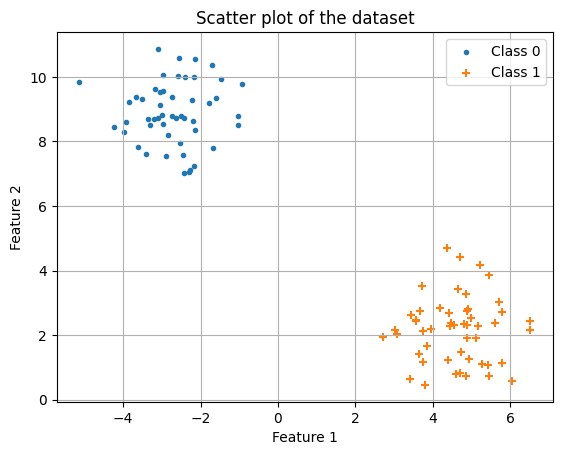

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate synthetic dataset
X, y = make_blobs(n_samples=100, centers=2, n_features=2, random_state=42)

# Separate the points based on their labels
class_0 = X[y == 0]
class_1 = X[y == 1]

# Plot the points
plt.scatter(class_0[:, 0], class_0[:, 1], marker='.', label='Class 0')
plt.scatter(class_1[:, 0], class_1[:, 1], marker='+', label='Class 1')

plt.title('Scatter plot of the dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


In [4]:
X = pd.DataFrame(X)
y[y == 0] = -1
y

array([-1,  1, -1,  1,  1, -1,  1,  1, -1, -1, -1,  1, -1, -1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1, -1, -1, -1, -1,
       -1,  1,  1, -1, -1, -1, -1,  1,  1,  1,  1, -1, -1, -1, -1,  1,  1,
       -1, -1,  1, -1,  1, -1,  1,  1, -1, -1,  1, -1,  1,  1,  1,  1, -1,
        1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1, -1, -1, -1,  1,
       -1, -1, -1,  1, -1,  1, -1, -1, -1, -1, -1, -1,  1, -1, -1])

In [6]:

SVM = SVMClassifier1(no_passes= 2)
alpha_optimal = SVM.fit(X,y)
alpha_optimal

#w_star = SVM.__w__(x_train,y_train,alpha_optimal)


[0.01573171 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.01573171 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
[0.0157317

array([0.01573171, 0.00384766, 0.        , 0.        , 0.        ,
       0.        , 0.01573171, 0.        , 0.        , 0.00036653,
       0.        , 0.        , 0.        , 0.        , 0.00150194,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.00377563, 0.        , 0.        , 0.00036653,
       0.        , 0.        , 0.00150194, 0.        , 0.00274654,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.00377563,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.00384766,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [7]:
m,n = X.shape
count = 0
for i in range(m):
  if (SVM.pridict(X.iloc[i])*y[i]) > 0:
    count += 1
count


100

In [8]:
w_optimal = SVM.w
b_optimal = SVM.b

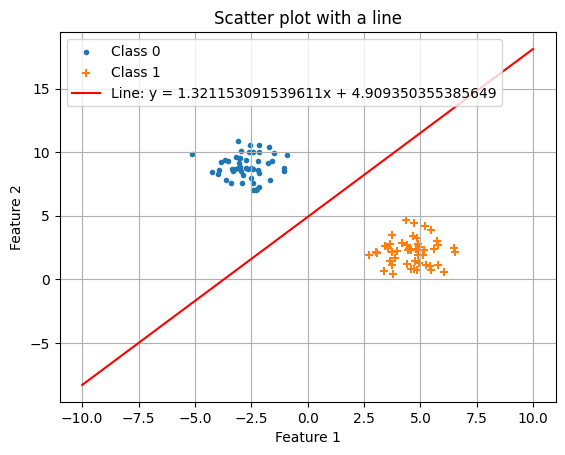

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs

# Generate synthetic dataset
X, y = make_blobs(n_samples=100, centers=2, n_features=2, random_state=42)

# Separate the points based on their labels
class_0 = X[y == 0]
class_1 = X[y == 1]

# Plot the points
plt.scatter(class_0[:, 0], class_0[:, 1], marker='.', label='Class 0')
plt.scatter(class_1[:, 0], class_1[:, 1], marker='+', label='Class 1')

# Define the slope (m) and y-intercept (c) of the line
m = -w_optimal[0]/w_optimal[1] # slope
c = -b_optimal/w_optimal[1]  # y-intercept

# Generate a range of x values for the line plot
x_line = np.linspace(-10, 10, 100)

# Calculate the corresponding y values
y_line = m * x_line + c

# Plot the line on the same plot as the scatter plot
plt.plot(x_line, y_line, '-r', label='Line: y = {}x + {}'.format(m, c))

plt.title('Scatter plot with a line')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()
